# 🔌 ElectroGyaan AI — Energy Consumption Analysis

## 🎯 Objective
- Detect anomalous energy usage
- Predict future consumption patterns

## 📂 Dataset Features
- flat_id
- timestamp
- units_kWh
- is_anomaly (ground truth)

## 🧠 Approach
1. Data Loading
2. Preprocessing
3. Feature Engineering
4. Exploratory Data Analysis (EDA)
5. Model Training
6. Model Evaluation
7. Model Export

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, mean_absolute_error, r2_score

import joblib

plt.style.use("ggplot")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving electrogyaan_dataset - electrogyaan_dataset.csv to electrogyaan_dataset - electrogyaan_dataset (2).csv


In [ ]:
df = pd.read_csv("electrogyaan_dataset - electrogyaan_dataset.csv")
df.head()

,flat_id,timestamp,units_kWh,is_anomaly
0,A101,2024-06-01 00:00:00,0.370,False
1,A101,2024-06-01 01:00:00,0.664,False
2,A101,2024-06-01 02:00:00,0.477,False
3,A101,2024-06-01 03:00:00,0.100,False
4,A101,2024-06-01 04:00:00,14.453,True


## 🔍 Data Inspection

We examine:
- Data types
- Missing values
- Basic statistics

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   flat_id     36000 non-null  object 
 1   timestamp   36000 non-null  object 
 2   units_kWh   36000 non-null  float64
 3   is_anomaly  36000 non-null  bool   
dtypes: bool(1), float64(1), object(2)
memory usage: 879.0+ KB


,units_kWh
count,36000.000000
mean,2.589267
std,2.631574
min,0.100000
25%,1.042000
50%,1.903000
75%,3.174000
max,14.999000


## 🧹 Data Preprocessing

- Convert timestamp to datetime
- Convert anomaly label to numeric

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["is_anomaly"] = df["is_anomaly"].astype(int)

## ⚙️ Feature Engineering

We extract time-based features and apply cyclical encoding:
- Hour of day
- hour_sin and hour_cos to capture cyclic nature of time

In [ ]:
df["hour"] = df["timestamp"].dt.hour

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df.head()

,flat_id,timestamp,units_kWh,is_anomaly,hour,hour_sin,hour_cos
0,A101,2024-06-01 00:00:00,0.370,0,0,0.000000,1.000000
1,A101,2024-06-01 01:00:00,0.664,0,1,0.258819,0.965926
2,A101,2024-06-01 02:00:00,0.477,0,2,0.500000,0.866025
3,A101,2024-06-01 03:00:00,0.100,0,3,0.707107,0.707107
4,A101,2024-06-01 04:00:00,14.453,1,4,0.866025,0.500000


## 📊 Distribution of Energy Consumption

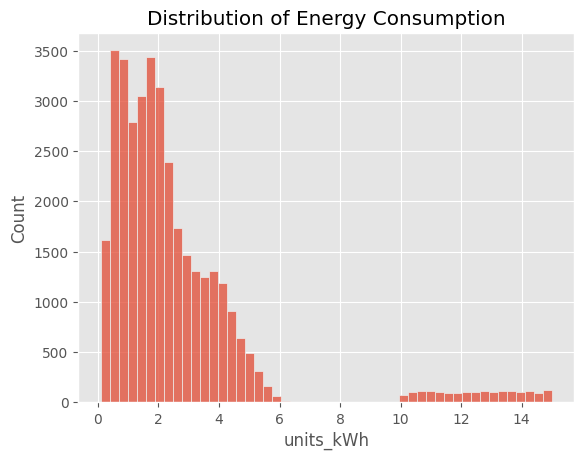

In [ ]:
sns.histplot(df["units_kWh"], bins=50)
plt.title("Distribution of Energy Consumption")
plt.show()

## 📦 Outlier Detection (Boxplot)

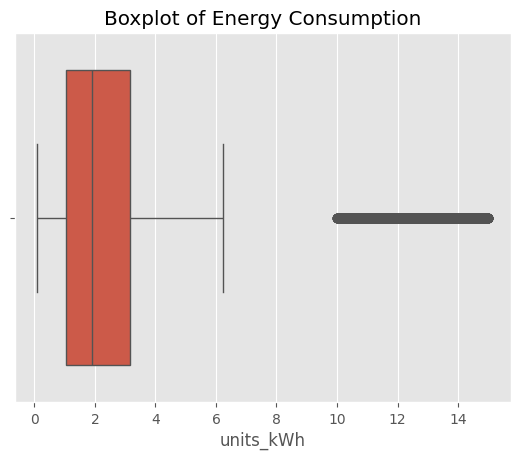

In [ ]:
sns.boxplot(x=df["units_kWh"])
plt.title("Boxplot of Energy Consumption")
plt.show()

## 📈 Hourly Energy Usage Trend

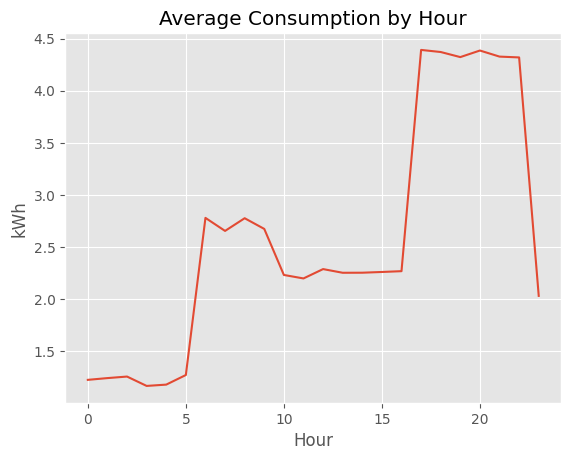

In [ ]:
hourly_avg = df.groupby("hour")["units_kWh"].mean()

hourly_avg.plot()
plt.title("Average Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("kWh")
plt.show()

## ✂️ Train-Test Split

We use time-based splitting to avoid data leakage.

In [ ]:
df = df.sort_values("timestamp")

split = int(0.8 * len(df))

train = df.iloc[:split]
test = df.iloc[split:]

## 🚨 Anomaly Detection using Isolation Forest

In [ ]:
features = ["hour_sin", "hour_cos", "units_kWh"]

iso_model = IsolationForest(contamination=0.05, random_state=42)
iso_model.fit(train[features])

IsolationForest(contamination=0.05, random_state=42)

In [ ]:
test["pred"] = iso_model.predict(test[features])
test["pred"] = test["pred"].map({1: 0, -1: 1})

print(classification_report(test["is_anomaly"], test["pred"]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6855
           1       1.00      1.00      1.00       345

    accuracy                           1.00      7200
   macro avg       1.00      1.00      1.00      7200
weighted avg       1.00      1.00      1.00      7200



/tmp/ipykernel_5045/2617630024.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["pred"] = iso_model.predict(test[features])
/tmp/ipykernel_5045/2617630024.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["pred"] = test["pred"].map({1: 0, -1: 1})


## 🔮 Energy Consumption Prediction using Linear Regression

In [ ]:
X_train = train[["hour_sin", "hour_cos"]]
y_train = train["units_kWh"]

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
X_test = test[["hour_sin", "hour_cos"]]
y_test = test["units_kWh"]

preds = lr_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R2 Score:", r2_score(y_test, preds))

MAE: 1.437096829205566
R2 Score: 0.07715642661047462


## 💾 Save Trained Models

These models will be used in FastAPI service.

In [ ]:
# joblib.dump(iso_model, "../models/iso_model.pkl")
# joblib.dump(lr_model, "../models/lr_model.pkl")

## 💡 Key Insights

- Energy usage peaks during morning and evening hours
- Majority of consumption values are within normal range
- Around 5% of readings are anomalies (spikes)
- Isolation Forest effectively detects abnormal patterns
- Linear Regression captures hourly trends reasonably well

## ⚠️ Limitations

- Synthetic dataset assumptions
- No weather or occupancy data
- Simple linear model used for prediction

## 🚀 Next Steps

- Deploy models via FastAPI
- Build real-time ingestion pipeline
- Visualize insights on dashboard